In [1]:
"""
    flower dataset
    224*224 rgb görüntüler mevcut

"""

'\n    flower dataset\n    224*224 rgb görüntüler mevcut\n\n'

In [13]:
#import librariries

from tensorflow.data import AUTOTUNE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Flatten,MaxPooling2D,Conv2D
from tensorflow.keras.optimizers import Adam #optimizer
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint,ReduceLROnPlateau
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow_datasets import load

In [16]:
#veri seti yükleme

(ds_train,ds_val),ds_info=load(
    "tf_flowers",
    split=["train[:80%]",#eğitim
          "train[80%:]"],#validation
    as_supervised=True,#görüntü etiket çiftini verecek burası
    with_info=True#veri seti hakkında veri
    
)


In [17]:
ds_info

tfds.core.DatasetInfo(
    name='tf_flowers',
    full_name='tf_flowers/3.0.1',
    description="""
    A large set of images of flowers
    """,
    homepage='https://www.tensorflow.org/tutorials/load_data/images',
    data_dir='C:\\Users\\Ömer faruk\\tensorflow_datasets\\tf_flowers\\3.0.1',
    file_format=tfrecord,
    download_size=218.21 MiB,
    dataset_size=221.83 MiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=5),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=3670, num_shards=2>,
    },
    citation="""@ONLINE {tfflowers,
    author = "The TensorFlow Team",
    title = "Flowers",
    month = "jan",
    year = "2019",
    url = "http://download.tensorflow.org/example_images/flower_photos.tgz" }""",
)

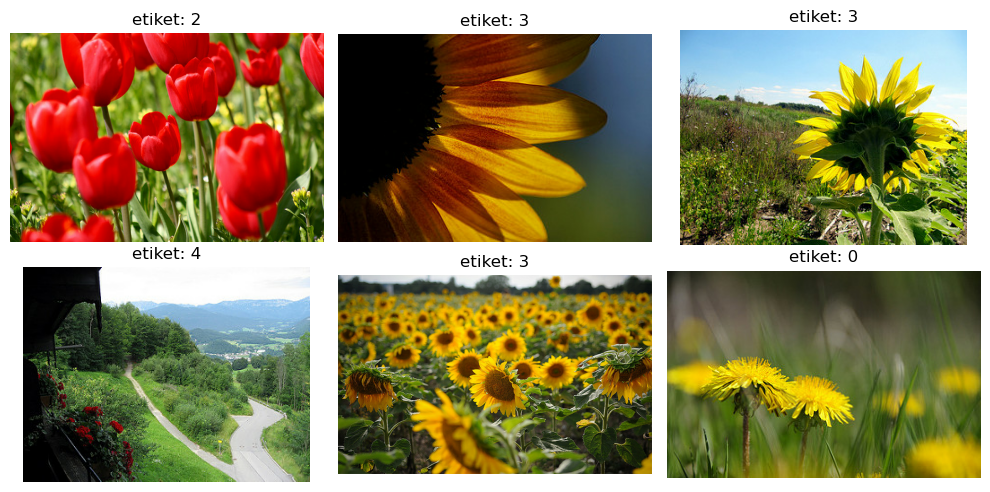

In [21]:
#enumarate kullanmamızın sebebi subplotu çizdirebilmek bu yüzden i değişkenide kullandık
fig=plt.figure(figsize=(10,5))
for i,(image,label) in enumerate(ds_train.take(6)):
    ax=fig.add_subplot(2,3,i+1)
    ax.imshow(image.numpy().astype("uint8"))
    ax.set_title(f"etiket: {label.numpy()}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [25]:
IMG_SIZE=(180,180)

In [26]:
#data augmentation

def preprocess_train(img,label):
    """
    eğitim verileri için ön işleme kısmı 
    resize,randomflip,brightness,contrast,crop ve en son normalize
    """
    img=tf.image.resize(img,IMG_SIZE)
    img=tf.image.random_flip_left_right(img)
    img=tf.image.random_brightness(img,max_delta=0.1)#max delta random parlaklık param
    img=tf.image.random_contrast(img,lower=0.9,upper=1.2)
    img=tf.image.random_crop(img,size=(160,160,3))
    img=tf.image.resize(img,IMG_SIZE)
    img=tf.cast(img,tf.float32)/255.0
    return img,label

def preprocess_val(img,label):
    img=tf.image.resize(img,IMG_SIZE)
    img=tf.cast(img,tf.float32)/255.0
    return img,label
    #val setine augment yapılmaz

In [27]:
ds_train=(ds_train.map(preprocess_train,num_parallel_calls=AUTOTUNE)
.shuffle(100)#karıstırma
.batch(32)# batch boyutu
.prefetch(AUTOTUNE)#veri setinin önceden hazırlanması

)

ds_val=(ds_val.map(preprocess_val,num_parallel_calls=AUTOTUNE).
       batch(32).
       prefetch(AUTOTUNE))

In [28]:
#modeli olusturma
"""
    3x3 matris kullanmamızın sebebi daha cok ayrıntı yakalamak ayrıca ilk başta 32 kullandık
    hiyerarşik olarak arttırıyoruz ki daha cok ozellik ogrensin



"""
model=Sequential(
[
    #feature extraction
    Conv2D(32,(3,3),activation="relu",input_shape=(*IMG_SIZE,3)),
    MaxPooling2D(),
    Conv2D(64,(3,3),activation="relu"),
    MaxPooling2D(),
    Conv2D(128,(3,3),activation="relu"),
    MaxPooling2D(),

    #classification layer
    Flatten(), #cok boyutlu veriyi vektore cevir
    Dense(128,activation="relu"),
    Dropout(0.5),
    Dense(ds_info.features["label"].num_classes,activation="softmax")




    
]


    
)

C:\Users\Ömer faruk\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
#callbacks

callbacks=[
    #eğer val_loss 3 epoch boyunca iyileşmezse durdur ve en  iyi agırlıkları yükle
    EarlyStopping(monitor="val_loss",patience=3,restore_best_weights=True),

    #val loss 2 epoch boyunca iyileşmezse lr'yi 0.2 carpanı ile azalt
    ReduceLROnPlateau(monitor="val_loss",factor=0.2,patience=2,verbose=1,min_lr=1e-9),

    #her epoch sonund eger model daha iyi ise kaydolur
    ModelCheckpoint("best_model.h5",save_best_only=True)
    
]

In [37]:
#derleme
model.compile(
             optimizer=Adam(learning_rate=0.001),
             loss= "sparse_categorical_crossentropy",
             metrics=["accuracy"]
)

In [38]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 178, 178, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 89, 89, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 87, 87, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 43, 43, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 41, 41, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 20, 20, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 51200)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       6,553,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,647,621 (25.36 MB)

 Trainable params: 6,647,621 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
history=model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=10,
    callbacks=callbacks,
    verbose=1
    
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.2816 - loss: 1.6252

92/92 ━━━━━━━━━━━━━━━━━━━━ 29s 297ms/step - accuracy: 0.2827 - loss: 1.6229 - val_accuracy: 0.5218 - val_loss: 1.1509 - learning_rate: 0.0010
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.5296 - loss: 1.1522

92/92 ━━━━━━━━━━━━━━━━━━━━ 27s 294ms/step - accuracy: 0.5299 - loss: 1.1518 - val_accuracy: 0.6485 - val_loss: 0.9372 - learning_rate: 0.0010
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 29s 315ms/step - accuracy: 0.5754 - loss: 1.0782 - val_accuracy: 0.6199 - val_loss: 0.9392 - learning_rate: 0.0010
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.6036 - loss: 1.0216

92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 268ms/step - accuracy: 0.6039 - loss: 1.0212 - val_accuracy: 0.6608 - val_loss: 0.8559 - learning_rate: 0.0010
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.6552 - loss: 0.9001

92/92 ━━━━━━━━━━━━━━━━━━━━ 26s 278ms/step - accuracy: 0.6553 - loss: 0.8999 - val_accuracy: 0.6907 - val_loss: 0.7846 - learning_rate: 0.0010
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 263ms/step - accuracy: 0.6616 - loss: 0.8843 - val_accuracy: 0.6880 - val_loss: 0.7895 - learning_rate: 0.0010
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.6578 - loss: 0.8841

92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 264ms/step - accuracy: 0.6580 - loss: 0.8838 - val_accuracy: 0.7057 - val_loss: 0.7226 - learning_rate: 0.0010
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 261ms/step - accuracy: 0.7104 - loss: 0.7877 - val_accuracy: 0.6839 - val_loss: 0.7576 - learning_rate: 0.0010
Epoch 9/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.7173 - loss: 0.7482

92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 258ms/step - accuracy: 0.7174 - loss: 0.7480 - val_accuracy: 0.7275 - val_loss: 0.7169 - learning_rate: 0.0010
Epoch 10/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 257ms/step - accuracy: 0.7208 - loss: 0.7381 - val_accuracy: 0.7016 - val_loss: 0.7826 - learning_rate: 0.0010


C:\Users\Ömer faruk\AppData\Local\Temp\ipykernel_18648\2276378388.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


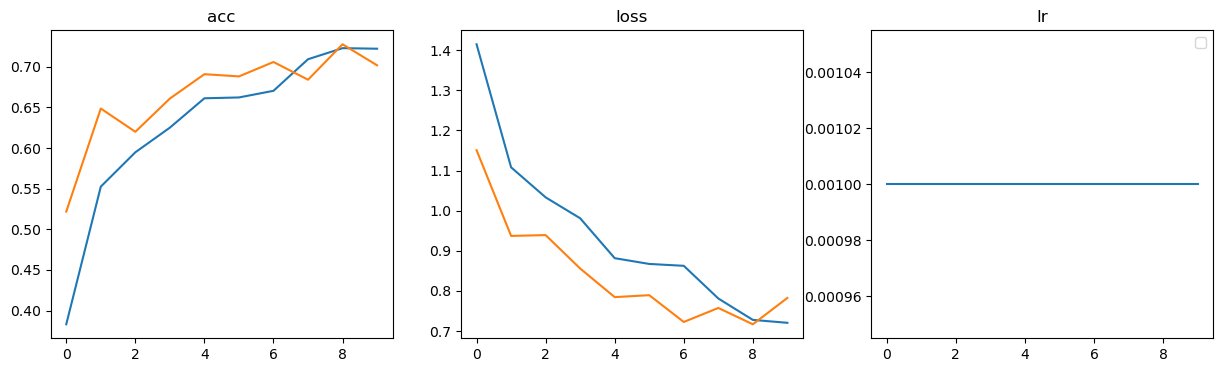

In [46]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.plot(history.history["accuracy"],label="training accuracy")
plt.plot(history.history["val_accuracy"],label="val_acc")
plt.title("acc")

plt.subplot(1,3,2)
plt.plot(history.history["loss"],label="training loss")
plt.plot(history.history["val_loss"],label="val_loss")
plt.title("loss")

plt.subplot(1,3,3)
plt.plot(history.history["learning_rate"])
plt.title("lr")

plt.legend()
plt.show()